In [12]:
import pathlib
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# load mask
fdir = '/work/bb1153/b382635/data/final_tracks/dcc_dev/anatomy_example_large/20210701/20210701T0000_20210702T0000_system_tracks.nc'
mask = xr.open_dataset(fdir)

In [14]:
# load data
dpath = '/work/bb1153/b382635/data/final_tracks/dcc_dev/anatomy_example_large/20210701/20210701T0000_20210702T0000_model_fields.nc'
data = xr.open_dataset(dpath)

In [15]:
# view tracked DCC labels, these are all the tracked DCCs in this dataset (0 is the background)
np.unique(mask.system)

array([ 0,  1,  2,  3,  4,  8, 14, 25, 41, 44, 55, 56, 57, 58, 59, 62, 63,
       68, 70, 73, 74, 78])

In [16]:
# view one DCC
sidx = 1
dcc = data.where(mask.system==1)

In [17]:
dcc

<xarray.Dataset> Size: 4GB
Dimensions:     (time: 95, level_full: 51, lat: 100, lon: 120)
Coordinates:
  * level_full  (level_full) int32 204B 40 41 42 43 44 45 ... 85 86 87 88 89 90
  * time        (time) datetime64[ns] 760B 2021-07-01T00:15:00 ... 2021-07-01...
    zg          (level_full, lat, lon) float32 2MB ...
  * lat         (lat) float64 800B 7.0 7.1 7.2 7.3 7.4 ... 16.6 16.7 16.8 16.9
  * lon         (lon) float64 960B -80.0 -79.9 -79.8 -79.7 ... -68.3 -68.2 -68.1
Data variables: (12/15)
    cli         (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    clw         (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    dzghalf     (level_full, lat, lon, time) float32 233MB nan nan ... nan nan
    hus         (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    pfull       (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    pr          (time, lat, lon, level_full) float32 233MB nan nan ... nan nan
    ...          ...
    rlut        (time, lat, lon, level_full) float32 233MB nan nan ... nan nan
    ta          (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    ts          (time, lat, lon, level_full) float32 233MB nan nan ... nan nan
    ua          (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    va          (time, level_full, lat, lon) float32 233MB nan nan ... nan nan
    wa_phy      (time, level_full, lat, lon) float64 465MB nan nan ... nan nan

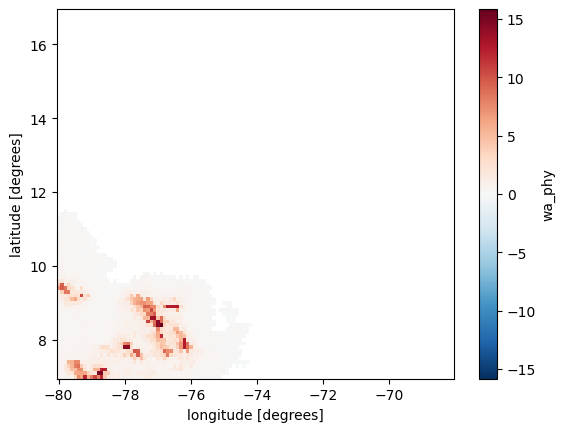

In [18]:
# max updraft
dcc.wa_phy.max(('level_full','time')).plot()

In [ ]:
# updraft vs condesate
w = dcc.wa_phy.max(('level_full','lat','lon')) # m s-1
q_vars = ['cli','clw','qg','qs','qr']
tot_q = xr.concat([dcc[q] for q in q_vars], dim='q').sum('q', skipna=True) # kg kg-1
q = tot_q.mean(('lat','lon','level_full'))

In [ ]:
fig, ax = plt.subplots()

w.plot(ax=ax, c='r', label='max updraft')
q.plot(ax=ax.twinx(), c='b', label='mean specific condensate')
fig.legend()